## Modèle de Machine Learning avec Scikit-learn

### 1. Fichier `requirements.txt`

Ce fichier liste les dépendances Python nécessaires pour exécuter le code ci-dessous. Vous pouvez installer ces dépendances en exécutant `pip install -r requirements.txt` dans votre terminal.

In [1]:
%%writefile requirements.txt
numpy
pandas
scikit-learn
matplotlib

Writing requirements.txt


### 2. Installation des dépendances

Exécutez la cellule suivante pour installer les bibliothèques requises dans l'environnement Colab.

In [2]:
!pip install -r requirements.txt

### 3. Importation des bibliothèques

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### 4. Génération de données d'exemple

Pour cet exemple, nous allons générer un jeu de données simple avec `numpy` et `pandas`.

In [4]:
# Générer des données aléatoires
np.random.seed(42)
X = np.random.rand(100, 2) * 10  # 100 échantillons, 2 caractéristiques
y = (X[:, 0] + X[:, 1] > 10).astype(int) # Classe binaire basée sur la somme des caractéristiques

# Créer un DataFrame pandas
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Target'] = y

display(df.head())

,Feature_1,Feature_2,Target
0,3.745401,9.507143,1
1,7.319939,5.986585,1
2,1.560186,1.559945,0
3,0.580836,8.661761,0
4,6.011150,7.080726,1


### 5. Séparation des données en ensembles d'entraînement et de test

In [5]:
X = df[['Feature_1', 'Feature_2']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement : {len(X_train)} échantillons")
print(f"Taille de l'ensemble de test : {len(X_test)} échantillons")

Taille de l'ensemble d'entraînement : 80 échantillons
Taille de l'ensemble de test : 20 échantillons


### 6. Création et entraînement du modèle de classification

Nous allons utiliser une régression logistique simple de `scikit-learn`.

In [6]:
# Initialiser le modèle de régression logistique
model = LogisticRegression(random_state=42)

# Entraîner le modèle
model.fit(X_train, y_train)

print("Modèle de régression logistique entraîné avec succès.")

Modèle de régression logistique entraîné avec succès.


### 7. Évaluation du modèle

In [7]:
# Faire des prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluer la précision du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle : {accuracy:.2f}")

# Afficher le rapport de classification
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Précision du modèle : 0.95

Rapport de classification :
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



### 8. Visualisation (facultatif)

Visualisons les données et la limite de décision du modèle.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


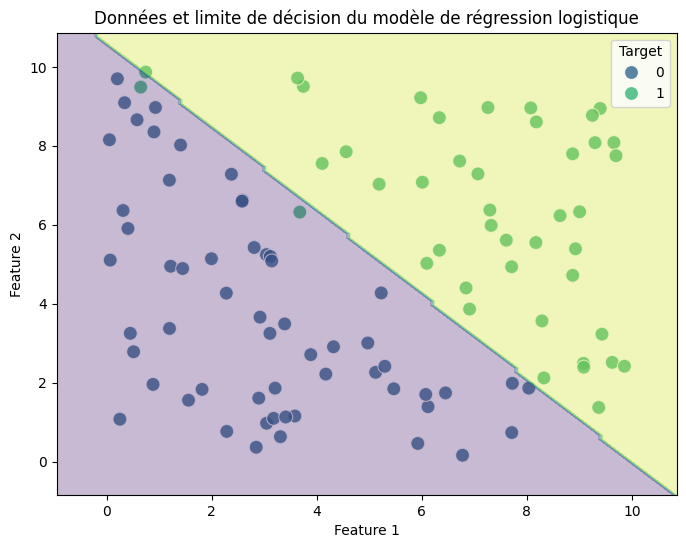

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['Feature_1'], y=X['Feature_2'], hue=y, palette='viridis', s=100, alpha=0.8)

# Créer un maillage pour la limite de décision
x_min, x_max = X['Feature_1'].min() - 1, X['Feature_1'].max() + 1
y_min, y_max = X['Feature_2'].min() - 1, X['Feature_2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title('Données et limite de décision du modèle de régression logistique')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Target')
plt.show()